Shape: (3000, 12)
Columns: ['Bus_ID', 'From', 'To', 'Distance_km', 'Traffic_Density', 'Is_Peak_Hour', 'Weather', 'Stops', 'Speed', 'Actual_Travel_Time', 'Is_Late', 'Is_Fastest_Route']


,Bus_ID,From,To,Distance_km,Traffic_Density,Is_Peak_Hour,Weather,Stops,Speed,Actual_Travel_Time,Is_Late,Is_Fastest_Route
0,SRT-B-0001,Pandesara,Varachha,44.77,5,0,Rainy,5,33.38,80.47,0,0
1,SRT-B-0002,Piplod,Udhna,11.55,5,0,Rainy,8,47.09,14.72,0,1
2,SRT-B-0003,Varachha,Rander,24.11,5,1,Cloudy,7,32.24,44.87,1,0
3,SRT-B-0004,Chikuwadi,Vesu,13.77,1,1,Rainy,7,33.03,25.01,1,0
4,SRT-B-0005,Varachha,Adajan,13.22,5,1,Foggy,1,36.50,21.73,1,0


,Bus_ID,From,To,Distance_km,Traffic_Density,Is_Peak_Hour,Weather,Stops,Speed,Actual_Travel_Time,Is_Late,Is_Fastest_Route
2995,SRT-B-2996,Udhna,Adajan,9.07,7,1,Foggy,5,41.90,12.99,1,1
2996,SRT-B-2997,Varachha,Godadara,49.87,6,1,Sunny,6,38.65,77.42,1,0
2997,SRT-B-2998,Adajan,Varachha,46.66,2,1,Sunny,4,36.47,76.77,1,0
2998,SRT-B-2999,Vesu,Chikuwadi,32.24,1,0,Cloudy,8,25.15,76.90,0,0
2999,SRT-B-3000,Pandesara,Udhna,33.80,7,1,Foggy,4,30.04,67.51,1,0


,Distance_km,Traffic_Density,Is_Peak_Hour,Stops,Speed,Actual_Travel_Time,Is_Late,Is_Fastest_Route
0,44.77,5,0,5,33.38,80.47,0,0
1,11.55,5,0,8,47.09,14.72,0,1
2,24.11,5,1,7,32.24,44.87,1,0
3,13.77,1,1,7,33.03,25.01,1,0
4,13.22,5,1,1,36.50,21.73,1,0
...,...,...,...,...,...,...,...,...
2995,9.07,7,1,5,41.90,12.99,1,1
2996,49.87,6,1,6,38.65,77.42,1,0
2997,46.66,2,1,4,36.47,76.77,1,0
2998,32.24,1,0,8,25.15,76.90,0,0


,Bus_ID,From,To,Weather
0,SRT-B-0001,Pandesara,Varachha,Rainy
1,SRT-B-0002,Piplod,Udhna,Rainy
2,SRT-B-0003,Varachha,Rander,Cloudy
3,SRT-B-0004,Chikuwadi,Vesu,Rainy
4,SRT-B-0005,Varachha,Adajan,Foggy
...,...,...,...,...
2995,SRT-B-2996,Udhna,Adajan,Foggy
2996,SRT-B-2997,Varachha,Godadara,Sunny
2997,SRT-B-2998,Adajan,Varachha,Sunny
2998,SRT-B-2999,Vesu,Chikuwadi,Cloudy


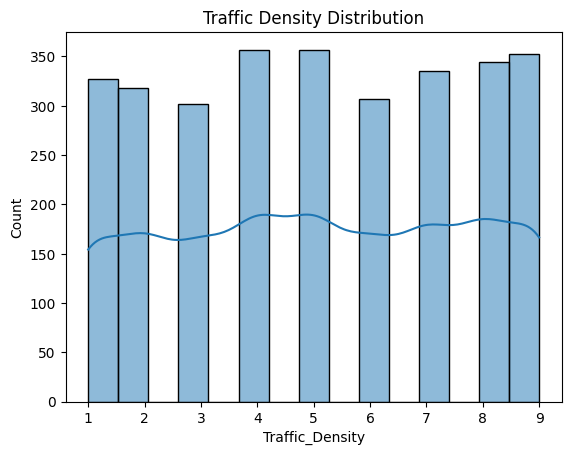

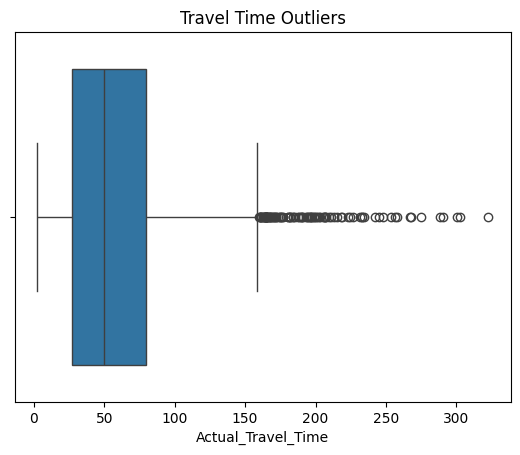

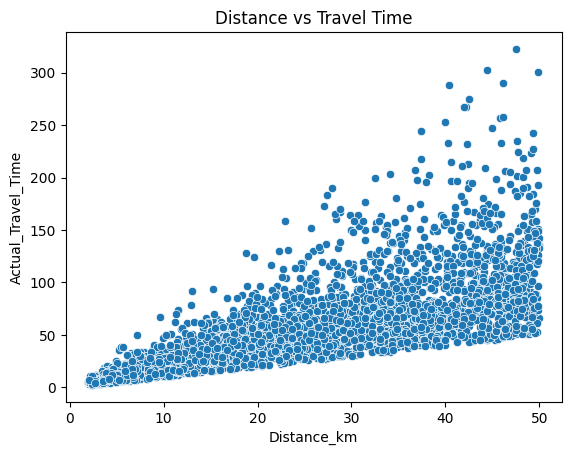

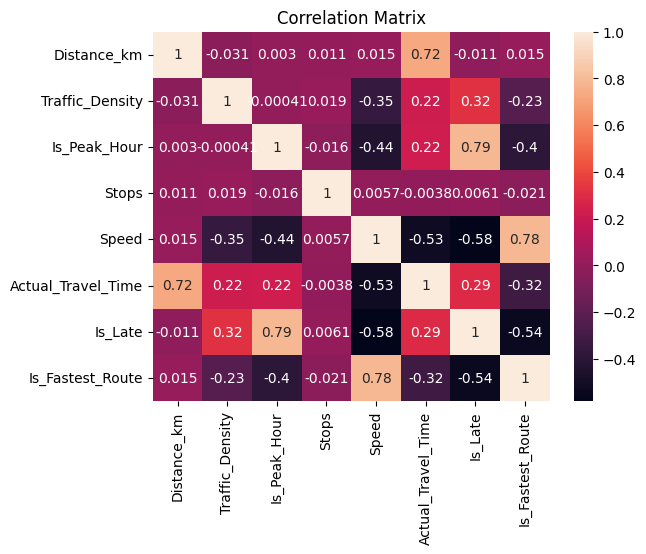

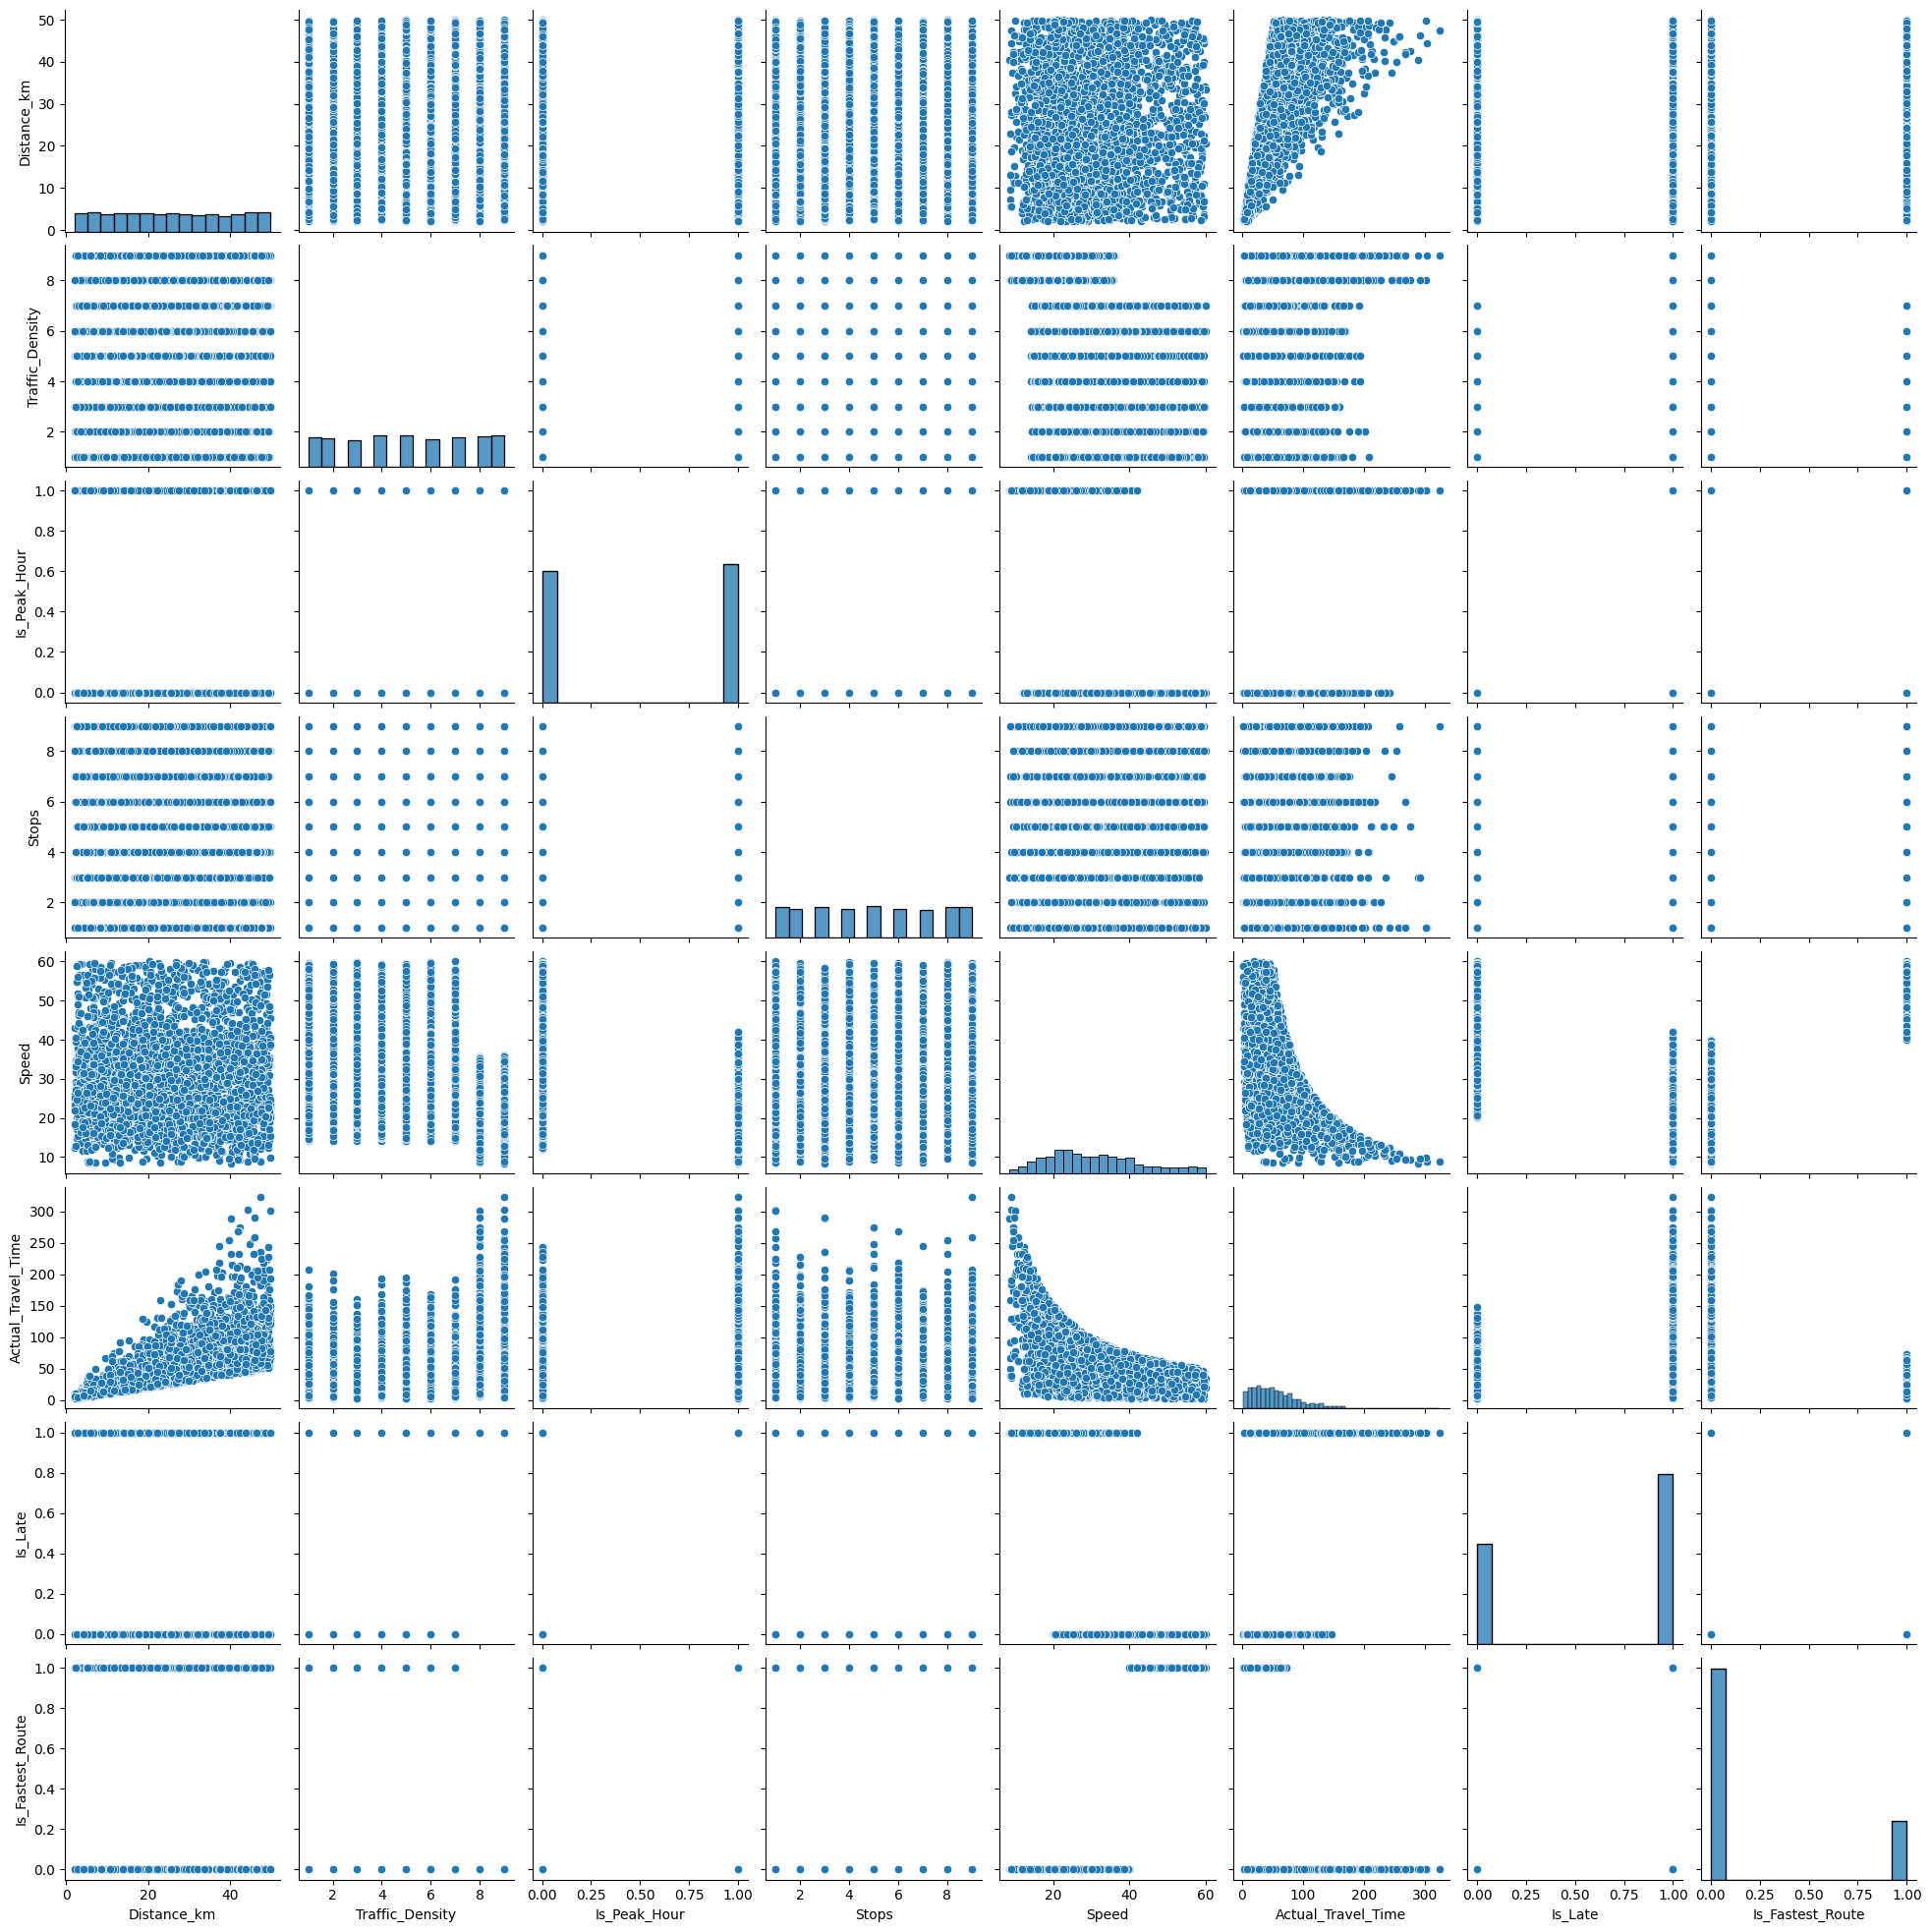


Missing Values:
 Bus_ID                0
From                  0
To                    0
Distance_km           0
Traffic_Density       0
Is_Peak_Hour          0
Weather               0
Stops                 0
Speed                 0
Actual_Travel_Time    0
Is_Late               0
Is_Fastest_Route      0
dtype: int64

===== REGRESSION =====
MSE: 18.39134083333333
R2: 0.989522375877806

===== CLASSIFICATION =====
Logistic Accuracy: 0.9966666666666667
 Random Forest Accuracy: 0.9783333333333334

Confusion Matrix:
 [[284   6]
 [  7 303]]


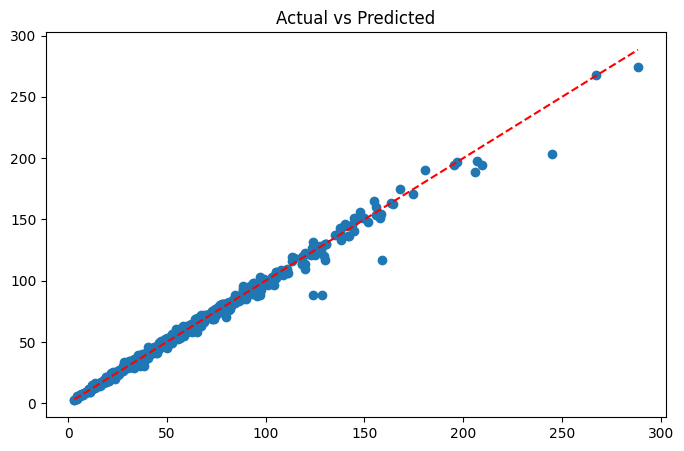

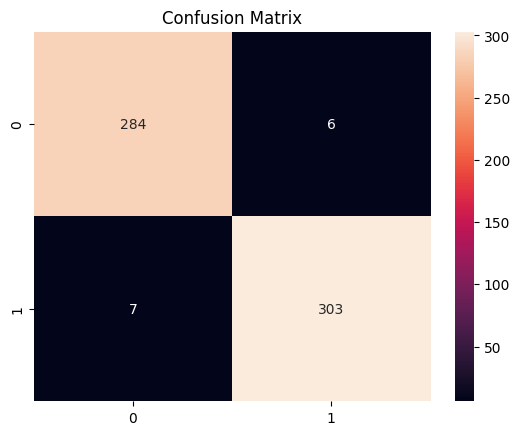


 MODEL SAVED SUCCESSFULLY!


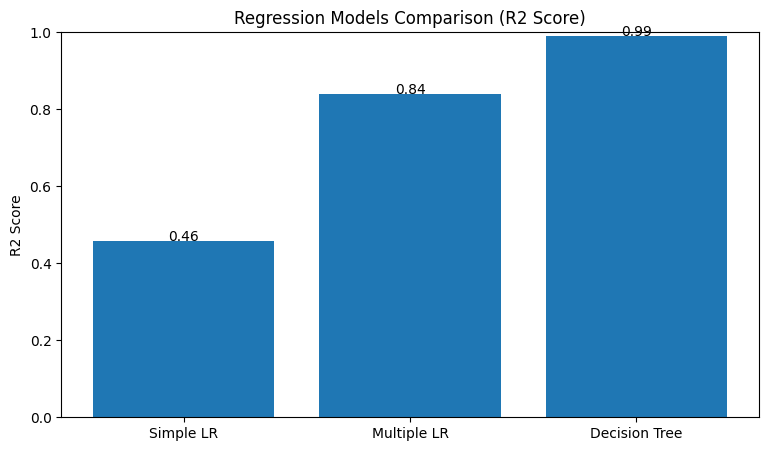

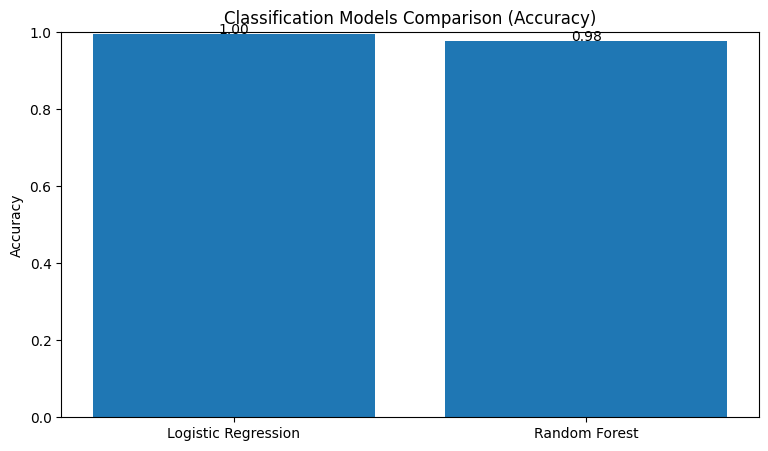

In [11]:

# Task 1: Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/smart_bus_dataset_3000.csv')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())
display(df.tail())

# EDA  (exploratry data analysis)

eda_df = df.copy()  

# Separate data types
num_df = eda_df.select_dtypes(include=np.number)     
display(num_df)   

cat_df = eda_df.select_dtypes(exclude=np.number)     
display(cat_df)   


# 🔹 Univariate Analysis
sns.histplot(eda_df['Traffic_Density'], kde=True)
plt.title("Traffic Density Distribution")
plt.show()

sns.boxplot(x=eda_df['Actual_Travel_Time'])
plt.title("Travel Time Outliers")
plt.show()

# 🔹 Bivariate Analysis
sns.scatterplot(x='Distance_km', y='Actual_Travel_Time', data=eda_df)
plt.title("Distance vs Travel Time")
plt.show()

# Only numeric for heatmap
numeric_df = eda_df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()


# 🔹 Multivariate Analysis (SAFE)
sns.pairplot(numeric_df)   
plt.show()


# Task 2: Data Cleaning

print("\nMissing Values:\n", df.isnull().sum())

df['Traffic_Density'] = df['Traffic_Density'].fillna(df['Traffic_Density'].median())
df['Distance_km'] = df['Distance_km'].fillna(df['Distance_km'].median())
df['Weather'] = df['Weather'].fillna('Sunny')

df.loc[df['Actual_Travel_Time'] < 0, 'Actual_Travel_Time'] = df['Actual_Travel_Time'].median()

# Task 3: Feature Engineering 


df['Speed'] = df['Distance_km'] / (df['Actual_Travel_Time'] + 1)
df['Peak_Traffic'] = df['Is_Peak_Hour'] * df['Traffic_Density']

df['Delay_Flag'] = (df['Actual_Travel_Time'] > df['Actual_Travel_Time'].median()).astype(int)

# Task 4: REMOVE STRING COLUMNS 


# Drop all non-numeric columns
df = df.select_dtypes(include=np.number)

# Task 5: Feature Selection


X = df.drop(['Actual_Travel_Time', 'Delay_Flag'], axis=1)
y_reg = df['Actual_Travel_Time']
y_clf = df['Delay_Flag']

# Task 6: Scaling


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Task 7: Train-Test Split


from sklearn.model_selection import train_test_split

X_train, X_test, y_train_reg, y_test_reg, y_train_clf, y_test_clf = train_test_split(
    X_scaled, y_reg, y_clf, test_size=0.2, random_state=42
)

# Task 8: Models


from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier

# 1. Simple Regression
simple_model = LinearRegression()
simple_model.fit(X_train[:, [0]], y_train_reg)
pred_simple = simple_model.predict(X_test[:, [0]])

# 2. Multiple Regression
multi_model = LinearRegression()
multi_model.fit(X_train, y_train_reg)
pred_multi = multi_model.predict(X_test)

# 3. Decision Tree
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train_reg)
pred_dt = dt_model.predict(X_test)

# 4. Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train_clf)
pred_log = log_model.predict(X_test)

# 5. Random Forest 
rf_model = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42)
rf_model.fit(X_train, y_train_clf)
pred_rf = rf_model.predict(X_test)

# Task 9: Evaluation


from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix

print("\n===== REGRESSION =====")
print("MSE:", mean_squared_error(y_test_reg, pred_dt))
print("R2:", r2_score(y_test_reg, pred_dt))

print("\n===== CLASSIFICATION =====")
print("Logistic Accuracy:", accuracy_score(y_test_clf, pred_log))
print(" Random Forest Accuracy:", accuracy_score(y_test_clf, pred_rf))

print("\nConfusion Matrix:\n", confusion_matrix(y_test_clf, pred_rf))

# Task 10: Final Graphs (Only 2 Clean)


# 1. Actual vs Predicted
plt.figure(figsize=(8,5))
plt.scatter(y_test_reg, pred_dt)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.title("Actual vs Predicted")
plt.show()

# 2. Confusion Matrix
sns.heatmap(confusion_matrix(y_test_clf, pred_rf), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# Task 11: Save Model

import joblib

joblib.dump(rf_model, 'model.pkl')
joblib.dump(list(X.columns), 'columns.pkl')

print("\n MODEL SAVED SUCCESSFULLY!")

# Regression Models (R2 Score)
plt.figure(figsize=(9,5))

models_reg = ['Simple LR', 'Multiple LR', 'Decision Tree']
scores_reg = [
    r2_score(y_test_reg, pred_simple),
    r2_score(y_test_reg, pred_multi),
    r2_score(y_test_reg, pred_dt)
]

bars = plt.bar(models_reg, scores_reg)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, yval, f"{yval:.2f}", ha='center')

plt.title("Regression Models Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.ylim(0,1)
plt.show()

# Classification Models (Accuracy
plt.figure(figsize=(9,5))

models_clf = ['Logistic Regression', 'Random Forest']
scores_clf = [
    accuracy_score(y_test_clf, pred_log),
    accuracy_score(y_test_clf, pred_rf)
]

bars = plt.bar(models_clf, scores_clf)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, yval, f"{yval:.2f}", ha='center')

plt.title("Classification Models Comparison (Accuracy)")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()